## Load jax with its settings and import KDExpress

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", 'cpu') # put 'gpu' here if you have one
import jax.numpy as jnp
import jax

import os,sys
parent_dir = os.getcwd() + '/../src/'
sys.path.append(parent_dir)
from KDExpress import fft_kde2d, silverman_bw2d, build_hist_edges

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

 ## Generate random weighted 2-D data 

/tmp/ipykernel_25957/2670387069.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = plt.cm.get_cmap('viridis')


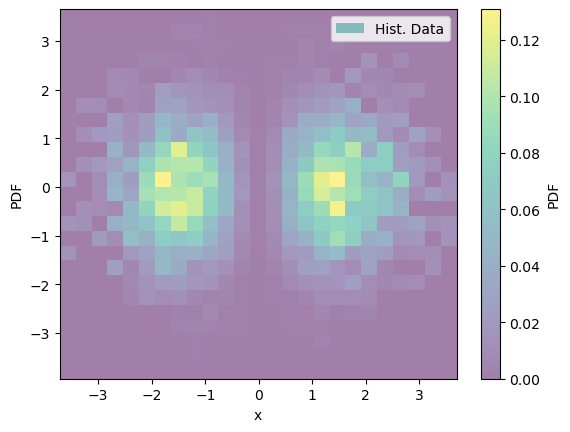

In [2]:
key = jax.random.PRNGKey(42)
data_2d = jax.random.normal(key, shape=(10_000, 2))
weights = (data_2d[:,0])**2

# Plot the 2D histogram and store the returned values
h = plt.hist2d(
    data_2d[:, 0], data_2d[:, 1], 
    weights=weights, 
    bins=25, 
    density=True, 
    alpha=0.5,
    cmap='viridis'  # Optional: for better visibility
)
plt.ylabel("PDF")
plt.xlabel("x")
viridis = plt.cm.get_cmap('viridis')
proxy_color = viridis(0.5) 
proxy_artist = Patch(facecolor=proxy_color, alpha=0.5, label='Hist. Data')
plt.legend(handles=[proxy_artist])

plt.colorbar(h[3], label='PDF')

plt.show()

## Define the points where evaluate the PDF and compute the bin edges surrounding them. The corresponding histogram is, again, less smooth.

Bin edges shape =  [(101,), (101,)]


/tmp/ipykernel_25957/1524462684.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = plt.cm.get_cmap('viridis')


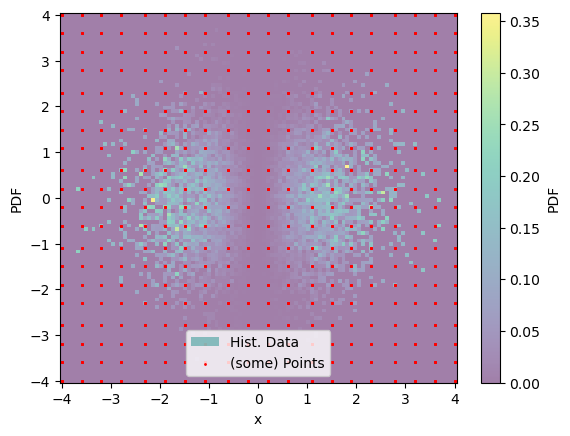

In [9]:
points_x = jnp.linspace(-4, 4, 100)
points_y = jnp.linspace(-4, 4, 100)
px, py = jnp.meshgrid(points_x, points_y, indexing='ij')
bin_edges = [build_hist_edges(points) for points in [points_x, points_y]]
print("Bin edges shape = ", [bin_edges[i].shape for i in range(2)])

h = plt.hist2d(
    data_2d[:, 0], data_2d[:, 1], 
    weights=weights, 
    bins=bin_edges, 
    density=True, 
    alpha=0.5,
    cmap='viridis'  # Optional: for better visibility
)
plt.ylabel("PDF")
plt.xlabel("x")
viridis = plt.cm.get_cmap('viridis')
proxy_color = viridis(0.5) 
ix = jnp.linspace(0,100,20).astype(int)
scatter_handle = plt.scatter(px[ix,:], py[:,ix], c='red', s=1 , label='(some) Points')
proxy_artist = Patch(facecolor=proxy_color, alpha=0.5, label='Hist. Data')
plt.legend(handles=[proxy_artist, scatter_handle])

plt.colorbar(h[3], label='PDF')

plt.show()

## We now compute the KDE as the convolution of the previous wavy histogram with a Gaussian Kernel. The convolution is (efficiently) done using a FFT.

Estimate bandwidths =  [0.19256654 0.19078095]


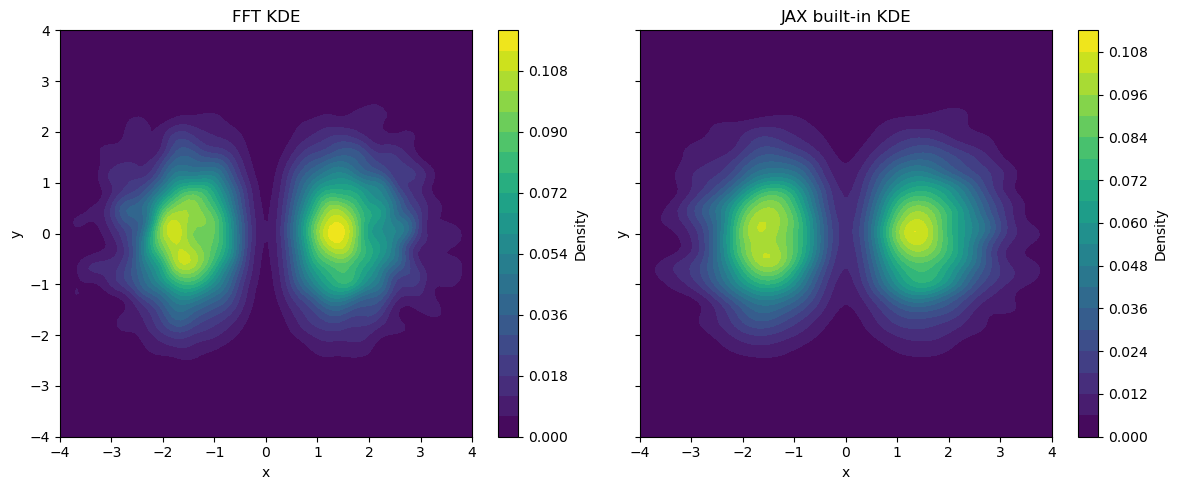

In [8]:
bw = silverman_bw2d(data_2d) # or a user defined value
print("Estimate bandwidths = ", bw)
pdf_est_fft = fft_kde2d(points_x, points_y, data_2d, weights=weights, bin_edges=bin_edges, bw=bw) # here we re-use bin_edges, but it isn't necessary

# jax built in kde
def jax_scipy_kde(x_grid, y_grid, data, weights=None, bw_method=None):
  kde = jax.scipy.stats.gaussian_kde(data.T, bw_method=bw_method, weights=weights)
  X, Y = jnp.meshgrid(x_grid, y_grid, indexing='ij')
  positions = jnp.vstack([X.ravel(), Y.ravel()])
  density = kde(positions).reshape(X.shape)
  return density
pdf_est_jax = jax_scipy_kde(points_x, points_y, data_2d, weights=weights, bw_method=0.5*(bw[0]+bw[1]))

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Plot FFT KDE
im1 = ax1.contourf(px, py, pdf_est_fft, levels=20, cmap='viridis')
ax1.set_title('FFT KDE')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(im1, ax=ax1, label='PDF')

# Plot JAX KDE
im2 = ax2.contourf(px, py, pdf_est_jax, levels=20, cmap='viridis')
ax2.set_title("JAX built-in KDE")
ax2.set_xlabel('x')
ax2.set_ylabel('y')
fig.colorbar(im2, ax=ax2, label='PDF')

plt.tight_layout()
plt.show()